#Upload Data

In [1]:
from google.colab import files
uploaded = files.upload()

Saving oil_sales_assignment_dataset.csv to oil_sales_assignment_dataset.csv


In [26]:
import pandas as pd
df = pd.read_csv(r"/content/oil_sales_assignment_dataset.csv")
df.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


#Understand Data

In [27]:
df.shape

(2000, 13)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   object 
 1   store_name     2000 non-null   object 
 2   manufacturer   2000 non-null   object 
 3   brand          2000 non-null   object 
 4   class          2000 non-null   object 
 5   size           2000 non-null   object 
 6   sku            2000 non-null   object 
 7   price_bracket  2000 non-null   object 
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 203.3+ KB


In [29]:
df.describe(include='all')

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
count,2000,2000,2000,2000,2000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
unique,12,1997,8,10,5,13,1571,10,NaN,NaN,NaN,NaN,NaN
top,AL BAHA,HM No 61276 GS-CENTER-TAIF MAIN RD TAIF,AL HILAL INDUSTRIES,HILAL,SUNFLOWER,1L,GULF GOLD COCONUT 3L TWIN PACK,21-30,NaN,NaN,NaN,NaN,NaN
freq,199,2,272,223,424,178,5,222,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.990500,6.639500,614.839355,9.972100,60.990230
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.820211,3.468942,750.794991,9.862369,29.457029
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,10.000000,794.100000,13.800000,81.000000


In [30]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']
print(f"{cat_cols} \n{'-'*50} \n{num_cols}")

['city', 'store_name', 'manufacturer', 'brand', 'class', 'size', 'sku', 'price_bracket'] 
-------------------------------------------------- 
['year', 'month', 'value_sales', 'volume_sales', 'average_price']


# Visualization of Data

###1. Visualization of Outliers

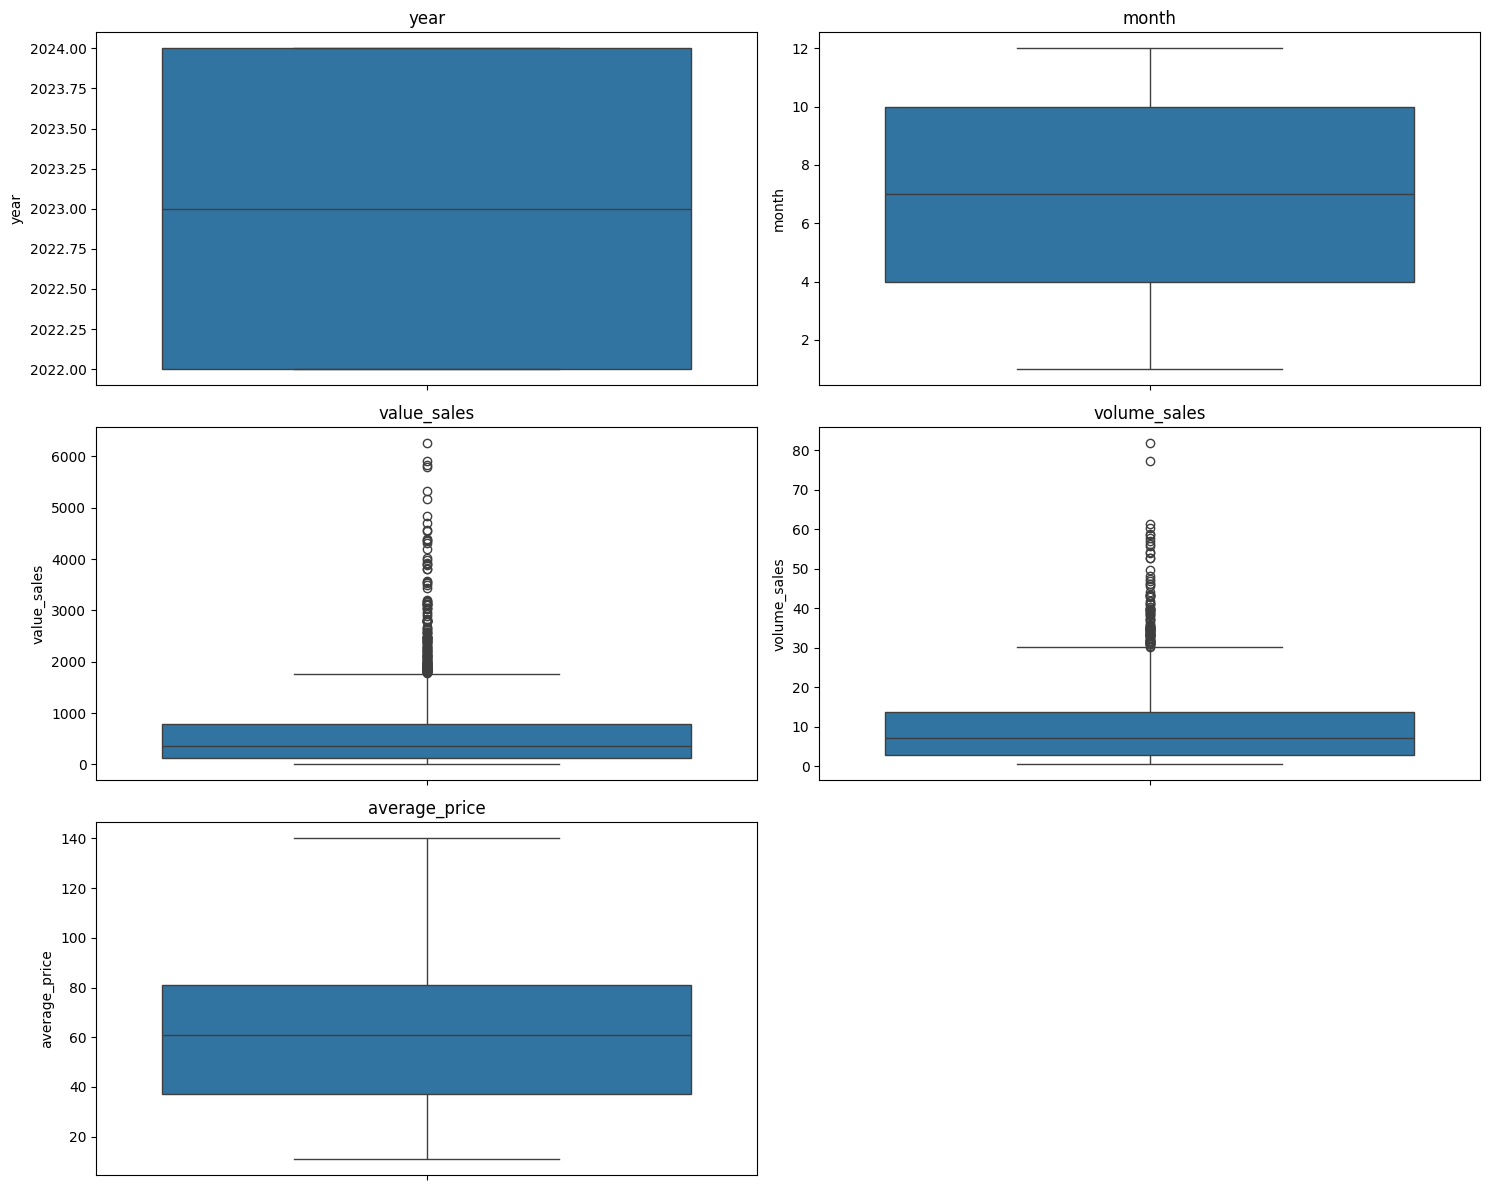

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) //2

fig, axes = plt.subplots(n_rows,n_cols,figsize=(15,n_rows*4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
  sns.boxplot(y=df[col], ax=axes[i])
  axes[i].set_title(col)

# Remove empty plots
for i in range(len(num_cols),len(axes)):
  axes[i].axis('off')

plt.tight_layout()
plt.show()


###2. Correlation Matrix

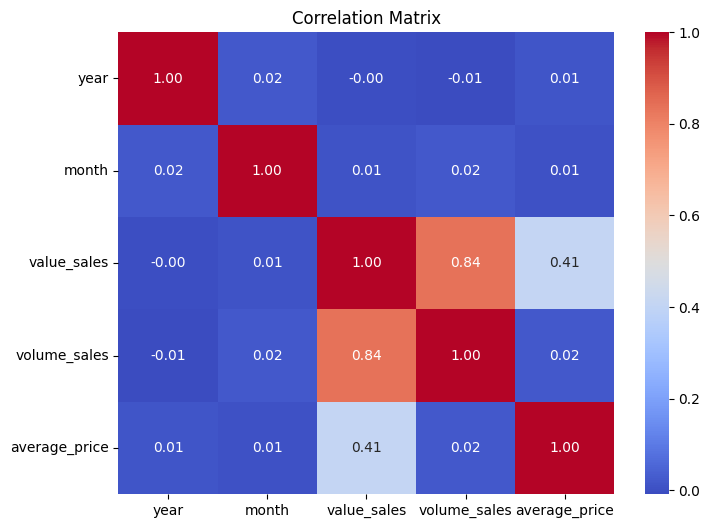

In [32]:
plt.figure(figsize=(8,6))
corr_mat = df.corr(numeric_only=True)
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

#Data Preprocessing

###1. Handle Duplicate Rows

In [33]:
df.duplicated().sum()

np.int64(0)

###2. Handle Missing Values

In [34]:
df.isna().sum()

,0
city,0
store_name,0
manufacturer,0
brand,0
class,0
size,0
sku,0
price_bracket,0
year,0
month,0


###3. Handle Outliers

In [35]:
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1

  lower = Q1-(1.5*IQR)
  upper = Q3+(1.5*IQR)

  print(f"{col}: {((df[col]<lower) | (df[col]>upper)).sum()} outliers")

year: 0 outliers
month: 0 outliers
value_sales: 147 outliers
volume_sales: 94 outliers
average_price: 0 outliers


In [36]:
for col in ['value_sales', 'volume_sales']:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1

  lower = Q1-(1.5*IQR)
  upper = Q3+(1.5*IQR)

  df = df[(df[col]>=lower) & (df[col]<=upper)]

  print(f"{col}: {((df[col]<lower) | (df[col]>upper)).sum()} outliers")

value_sales: 0 outliers
volume_sales: 0 outliers


###4. Drop Useless Columns

In [37]:
#  Since sku = brand + class + size -> Drop sku
df = df.drop(columns=['sku'])
#  Since 'store_name' is not important -> Drop it
df = df.drop(columns=['store_name'])
#  Since 'price_bracket' is not important -> Drop it
df = df.drop(columns=['price_bracket'])
df.tail()

,city,manufacturer,brand,class,size,year,month,value_sales,volume_sales,average_price
1995,TABUK,NAJDI CONSUMER,LARA,COCONUT,0.5L,2024,11,74.4,2.4,31.0
1996,AL AHSA,BLUE OASIS CO,LARA,SUNFLOWER,3L,2022,5,20.0,0.5,40.0
1997,AL KHARJ,NOVA FOODS,NOUR,SUNFLOWER,2.9L,2023,8,527.8,5.8,91.0
1998,RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,2024,6,305.0,5.0,61.0
1999,JEDDAH,NAJDI CONSUMER,BAYTNA,COCONUT,1.8L,2022,4,181.8,1.8,101.0


###5. Handle Columns values

In [38]:
#  Remove 'L' from 'size' column values then convert to float
df['size'] = df['size'].str.replace('L', '', regex=False)
df['size'] = df['size'].astype(float)
df['size']

,size
1,0.50
2,0.75
3,0.60
4,1.00
6,1.80
...,...
1995,0.50
1996,3.00
1997,2.90
1998,0.75


In [39]:
#  Apply One Hot Encoding in nominal column 'city'
df = pd.get_dummies(df,columns=['city'], dtype= int)
df.head()

,manufacturer,brand,class,size,year,month,value_sales,volume_sales,average_price,city_AL AHSA,...,city_AL KHARJ,city_DAMMAM,city_HAIL,city_JAZAN,city_JEDDAH,city_MAKKAH,city_RIYADH,city_TABUK,city_TAIF,city_YANBU
1,PALM & GRAIN GROUP,NAJMA,CANOLA,0.50,2024,10,373.1,9.1,41.0,0,...,1,0,0,0,0,0,0,0,0,0
2,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75,2023,1,171.7,1.7,101.0,0,...,0,0,0,0,0,0,1,0,0,0
3,PALM & GRAIN GROUP,NOUR,CORN,0.60,2022,2,1226.1,20.1,61.0,0,...,0,1,0,0,0,0,0,0,0,0
4,DESERT SUN CO,NOUR,VEGETABLE,1.00,2024,2,996.3,12.3,81.0,0,...,0,0,0,1,0,0,0,0,0,0
6,ARABIAN HARVEST CO,HILAL,CANOLA,1.80,2024,6,194.4,2.4,81.0,0,...,0,0,0,0,0,0,0,0,1,0


In [40]:
#  Apply One Hot Encoding in nominal column 'brand'
df = pd.get_dummies(df,columns=['brand'], dtype= int)
df.tail()

,manufacturer,class,size,year,month,value_sales,volume_sales,average_price,city_AL AHSA,city_AL BAHA,...,brand_BAYTNA,brand_GULF GOLD,brand_HILAL,brand_LARA,brand_NAJMA,brand_NOUR,brand_RAWABI,brand_RIMAL,brand_SABAYA,brand_ZAHRA
1995,NAJDI CONSUMER,COCONUT,0.50,2024,11,74.4,2.4,31.0,0,0,...,0,0,0,1,0,0,0,0,0,0
1996,BLUE OASIS CO,SUNFLOWER,3.00,2022,5,20.0,0.5,40.0,1,0,...,0,0,0,1,0,0,0,0,0,0
1997,NOVA FOODS,SUNFLOWER,2.90,2023,8,527.8,5.8,91.0,0,0,...,0,0,0,0,0,1,0,0,0,0
1998,NOVA FOODS,CORN,0.75,2024,6,305.0,5.0,61.0,0,0,...,0,0,0,0,1,0,0,0,0,0
1999,NAJDI CONSUMER,COCONUT,1.80,2022,4,181.8,1.8,101.0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [41]:
#  Apply One Hot Encoding in nominal column 'manufacturer'
df = pd.get_dummies(df,columns=['manufacturer'], dtype= int)
df.head()

,class,size,year,month,value_sales,volume_sales,average_price,city_AL AHSA,city_AL BAHA,city_AL KHARJ,...,brand_SABAYA,brand_ZAHRA,manufacturer_AL HILAL INDUSTRIES,manufacturer_ARABIAN HARVEST CO,manufacturer_BLUE OASIS CO,manufacturer_DESERT SUN CO,manufacturer_NAJDI CONSUMER,manufacturer_NOVA FOODS,manufacturer_PALM & GRAIN GROUP,manufacturer_SAHARA EDIBLES
1,CANOLA,0.50,2024,10,373.1,9.1,41.0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,SUNFLOWER,0.75,2023,1,171.7,1.7,101.0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,CORN,0.60,2022,2,1226.1,20.1,61.0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,VEGETABLE,1.00,2024,2,996.3,12.3,81.0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
6,CANOLA,1.80,2024,6,194.4,2.4,81.0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [42]:
#  Apply One Hot Encoding in nominal column 'class'
df = pd.get_dummies(df,columns=['class'], dtype= int)
df.tail()

,size,year,month,value_sales,volume_sales,average_price,city_AL AHSA,city_AL BAHA,city_AL KHARJ,city_DAMMAM,...,manufacturer_DESERT SUN CO,manufacturer_NAJDI CONSUMER,manufacturer_NOVA FOODS,manufacturer_PALM & GRAIN GROUP,manufacturer_SAHARA EDIBLES,class_CANOLA,class_COCONUT,class_CORN,class_SUNFLOWER,class_VEGETABLE
1995,0.50,2024,11,74.4,2.4,31.0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
1996,3.00,2022,5,20.0,0.5,40.0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1997,2.90,2023,8,527.8,5.8,91.0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
1998,0.75,2024,6,305.0,5.0,61.0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
1999,1.80,2022,4,181.8,1.8,101.0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0


# Modeling

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df.drop(columns=['value_sales'])
y = df['value_sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [50]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_test)

print(f"MAE: {mae:.2f}")

MAE: 106.86


In [51]:
df['value_sales'].describe()

,value_sales
count,1789.000000
mean,429.640654
std,396.301915
min,6.960000
25%,114.800000
50%,305.000000
75%,626.200000
max,1767.500000


In [52]:
print(f"Relative MAE: {mae/df['value_sales'].mean()*100:.3f}%")

Relative MAE: 24.871%


In [53]:
from sklearn.metrics import r2_score
rscore_train = r2_score(y_train,y_pred_train)
rscore_test = r2_score(y_test,y_pred_test)
print(f"R2 sore train: {rscore_train}")
print(f"R2 sore test: {rscore_test}")

R2 sore train: 0.8504862026709336
R2 sore test: 0.858104867841366


In [54]:
df.columns.tolist()

['size',
 'year',
 'month',
 'value_sales',
 'volume_sales',
 'average_price',
 'city_AL AHSA',
 'city_AL BAHA',
 'city_AL KHARJ',
 'city_DAMMAM',
 'city_HAIL',
 'city_JAZAN',
 'city_JEDDAH',
 'city_MAKKAH',
 'city_RIYADH',
 'city_TABUK',
 'city_TAIF',
 'city_YANBU',
 'brand_BAYTNA',
 'brand_GULF GOLD',
 'brand_HILAL',
 'brand_LARA',
 'brand_NAJMA',
 'brand_NOUR',
 'brand_RAWABI',
 'brand_RIMAL',
 'brand_SABAYA',
 'brand_ZAHRA',
 'manufacturer_AL HILAL INDUSTRIES',
 'manufacturer_ARABIAN HARVEST CO',
 'manufacturer_BLUE OASIS CO',
 'manufacturer_DESERT SUN CO',
 'manufacturer_NAJDI CONSUMER',
 'manufacturer_NOVA FOODS',
 'manufacturer_PALM & GRAIN GROUP',
 'manufacturer_SAHARA EDIBLES',
 'class_CANOLA',
 'class_COCONUT',
 'class_CORN',
 'class_SUNFLOWER',
 'class_VEGETABLE']